<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Data">Data</a></li>
        <li><a href="#Selecting-And-Preprocessing">Selecting And Preprocessing</a></li>
        <li><a href="#Data-split">Data split</a></li>
        <li><a href="#Model-And-Evaluation">Model And Evaluation</a></li>
        <li><a href="#Confusion-Matrix">Confusion Matrix</a></li>
    </ol>
</div>
<br>
<hr>

<a id="ref1"></a>

## What is the difference between Linear and Logistic Regression?

While Linear Regression is suited for estimating continuous values (e.g. estimating house price), it is not the best tool for predicting the class of an observed data point. In order to estimate the class of a data point, we need some sort of guidance on what would be the <b>most probable class</b> for that data point. For this, we use <b>Logistic Regression</b>.

<div class="alert alert-success alertsuccess" style="margin-top: 20px">
<font size = 3><strong>Recall linear regression:</strong></font>
<br>
<br>
    As you know, <b>Linear regression</b> finds a function that relates a continuous dependent variable, <b>y</b>, to some predictors (independent variables $x_1$, $x_2$, etc.). For example, simple linear regression assumes a function of the form:
<br><br>
$$
y = \theta_0 + \theta_1  x_1 + \theta_2  x_2 + \cdots
$$
<br>
and finds the values of parameters $\theta_0, \theta_1, \theta_2$, etc, where the term $\theta_0$ is the "intercept". It can be generally shown as:
<br><br>
$$
ℎ_\theta(𝑥) = \theta^TX
$$
<p></p>

</div>

Logistic Regression is a variation of Linear Regression, useful when the observed dependent variable, <b>y</b>, is categorical. It produces a formula that predicts the probability of the class label as a function of the independent variables.

Logistic regression fits a special s-shaped curve by taking the linear regression function and transforming the numeric estimate into a probability with the following function, which is called the sigmoid function 𝜎:

$$
ℎ\_\theta(𝑥) = \sigma({\theta^TX}) =  \frac {e^{(\theta\_0 + \theta\_1  x\_1 + \theta\_2  x\_2 +...)}}{1 + e^{(\theta\_0 + \theta\_1  x\_1 + \theta\_2  x\_2 +\cdots)}}
$$
Or:
$$
ProbabilityOfaClass\_1 =  P(Y=1|X) = \sigma({\theta^TX}) = \frac{e^{\theta^TX}}{1+e^{\theta^TX}}
$$

In this equation, ${\theta^TX}$ is the regression result (the sum of the variables weighted by the coefficients), `exp` is the exponential function and $\sigma(\theta^TX)$ is the sigmoid or [logistic function](http://en.wikipedia.org/wiki/Logistic_function?utm_medium=Exinfluencer\&utm_source=Exinfluencer\&utm_content=000026UJ\&utm_term=10006555\&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01), also called logistic curve. It is a common "S" shape (sigmoid curve).

So, briefly, Logistic Regression passes the input through the logistic/sigmoid but then treats the result as a probability:

<img
src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/images/mod_ID_24_final.png" width="400" align="center">

The objective of the **Logistic Regression** algorithm, is to find the best parameters θ, for $ℎ\_\theta(𝑥)$ = $\sigma({\theta^TX})$, in such a way that the model best predicts the class of each case.
<hr>

# import libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import scipy.optimize as opt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import itertools

<h1 label = "#Data">Data</h1>

In [2]:
df = pd.read_csv("../data/ChurnData.csv")
print(df.shape)
df

(200, 28)


,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


<h1 label = "#Selecting-And-Preprocessing">Selecting And Preprocessing</h1>

In [3]:
df = df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip','churn']]
df['churn'] == df['churn'].astype('int')
df.head()

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0.0


In [4]:
X = np.asarray(df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']])
print(X[:5])
Y = np.asarray(df["churn"])
Y[:5]

[[ 11.  33.   7. 136.   5.   5.   0.]
 [ 33.  33.  12.  33.   2.   0.   0.]
 [ 23.  30.   9.  30.   1.   2.   0.]
 [ 38.  35.   5.  76.   2.  10.   1.]
 [  7.  35.  14.  80.   2.  15.   0.]]


array([1., 1., 0., 0., 0.])

$$ z = \frac {(x-\mu)} {\sigma} $$

In [5]:
Scaler = StandardScaler().fit(X)
X = Scaler.transform(X)
X[:5]

array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695]])

<h1 label = "#Data-split">Data split</h1>

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (160, 7) (160,)
Test set: (40, 7) (40,)


<h1 label = "#Model-And-Evaluation">Model And Evaluation</h1>

Let's build our model using **LogisticRegression** from the Scikit-learn package. This function implements logistic regression and can use different numerical optimizers to find parameters, including ‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’ solvers. You can find extensive information about the pros and cons of these optimizers if you search it in the internet.

The version of Logistic Regression in Scikit-learn, support regularization. Regularization is a technique used to solve the overfitting problem of machine learning models.
**C** parameter indicates **inverse of regularization strength** which must be a positive float. Smaller values specify stronger regularization.
Now let's fit our model with train set:
<hr>

In [7]:
from IPython.display import display, HTML

with open("../html/logreg_reference.html", encoding="utf-8") as f:
    display(HTML(f.read()))

In [ ]:
LogisticRegression?

In [8]:
solver_configs = [

    {"solver": "liblinear", "l1_ratio": 1},       # L1

    {"solver": "liblinear", "l1_ratio": 0},       # L2

    {"solver": "lbfgs"},                           # L2 (default)

    {"solver": "saga",  "l1_ratio": 1},            # L1

    {"solver": "saga",  "l1_ratio": 0},            # L2

    {"solver": "saga",  "l1_ratio": 0.5},          # ElasticNet

    {"solver": "sag"},                             # L2 (default)

    {"solver": "newton-cg"},                       # L2 (default)

    {"solver": "newton-cholesky"},                 # L2 (default)

]

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for config in solver_configs:

    for C in C_values:

        try:

            model = LogisticRegression(**config, C=C, max_iter=1000)

            model.fit(X_train, y_train)

            score = model.score(X_test, y_test)

            results.append({

                "solver":   config["solver"],

                "l1_ratio": config.get("l1_ratio", 0),

                "C":        C,

                "accuracy": round(score, 4)

            })

        except Exception:

            pass

df = pd.DataFrame(results).sort_values("accuracy", ascending=False)

print(df.head(10))

       solver  l1_ratio        C  accuracy
7   liblinear       0.0    0.010     0.750
4   liblinear       1.0   10.000     0.725
5   liblinear       1.0  100.000     0.725
8   liblinear       0.0    0.100     0.725
6   liblinear       0.0    0.001     0.725
3   liblinear       1.0    1.000     0.725
21       saga       1.0    1.000     0.725
17      lbfgs       0.0  100.000     0.725
16      lbfgs       0.0   10.000     0.725
9   liblinear       0.0    1.000     0.725


In [9]:
solver_configs = [
    {"solver": "liblinear", "l1_ratio": 1},       # L1
    {"solver": "liblinear", "l1_ratio": 0},       # L2
    {"solver": "lbfgs"},                           # L2 (default)
    {"solver": "saga",  "l1_ratio": 1},            # L1
    {"solver": "saga",  "l1_ratio": 0},            # L2
    {"solver": "saga",  "l1_ratio": 0.5},          # ElasticNet
    {"solver": "sag"},                             # L2 (default)
    {"solver": "newton-cg"},                       # L2 (default)
    {"solver": "newton-cholesky"},                 # L2 (default)
]

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = []

for config in solver_configs:
    for C in C_values:
        try:
            model = LogisticRegression(**config, C=C, max_iter=1000)
            model.fit(X_train, y_train)
            yhat = model.predict(X_test)
            cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
            FN = cnf_matrix[0][1]
            results.append({
                "solver":   config["solver"],
                "l1_ratio": config.get("l1_ratio", 0),
                "C":        C,
                "FN": round(FN, 4)
            })
        except Exception:
            pass

df = pd.DataFrame(results).sort_values("FN", ascending=True)
print(df.head(10))

       solver  l1_ratio        C  FN
6   liblinear       0.0    0.001   6
7   liblinear       0.0    0.010   9
3   liblinear       1.0    1.000  11
2   liblinear       1.0    0.100  11
5   liblinear       1.0  100.000  11
4   liblinear       1.0   10.000  11
9   liblinear       0.0    1.000  11
8   liblinear       0.0    0.100  11
15      lbfgs       0.0    1.000  11
14      lbfgs       0.0    0.100  11


In [10]:
LR = LogisticRegression(C = 0.001 , solver = "liblinear").fit(X_train,y_train)

In [11]:
yhat = LR.predict(X_test)
print(yhat)
print(y_test)

[0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0.
 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1.]
[0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0.]


In [12]:
LR.predict_proba(X_test)

array([[0.5055063 , 0.4944937 ],
       [0.51347317, 0.48652683],
       [0.50602462, 0.49397538],
       [0.52000045, 0.47999955],
       [0.50661998, 0.49338002],
       [0.50673336, 0.49326664],
       [0.49839547, 0.50160453],
       [0.51405871, 0.48594129],
       [0.48122787, 0.51877213],
       [0.51944971, 0.48055029],
       [0.51298723, 0.48701277],
       [0.52293885, 0.47706115],
       [0.48984113, 0.51015887],
       [0.48407622, 0.51592378],
       [0.52861954, 0.47138046],
       [0.5092273 , 0.4907727 ],
       [0.50191901, 0.49808099],
       [0.49233906, 0.50766094],
       [0.49487978, 0.50512022],
       [0.49864676, 0.50135324],
       [0.51699424, 0.48300576],
       [0.50364772, 0.49635228],
       [0.51953823, 0.48046177],
       [0.50404011, 0.49595989],
       [0.49833478, 0.50166522],
       [0.5372498 , 0.4627502 ],
       [0.51029376, 0.48970624],
       [0.50165227, 0.49834773],
       [0.49767905, 0.50232095],
       [0.53805393, 0.46194607],
       [0.

<h1 label ="#Confusion-Matrix">Confusion Matrix</h1>

In [13]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, yhat, labels=[1,0]))

[[ 9  6]
 [ 5 20]]


Confusion matrix, without normalization
[[ 9  6]
 [ 5 20]]


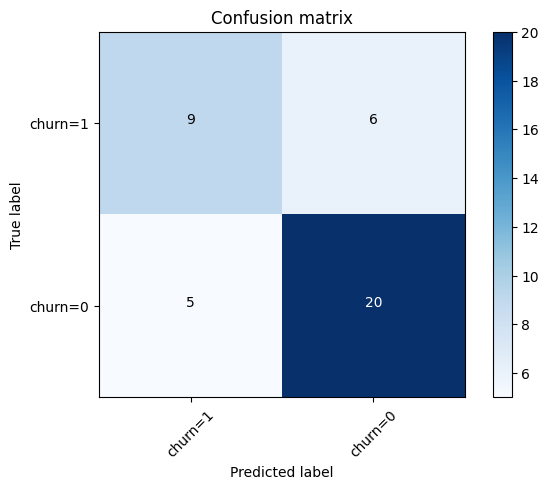

In [14]:

cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)


plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'],normalize= False,  title='Confusion matrix')